<table>
  <tr>
    <td>Minería de Datos y Paradigma BigData (<b>MIN</b>) - Facultad de Informática - UCM</td>
    <td><img src="https://biblioteca.ucm.es/data/cont/media/www/pag-88746//escudo.jpg" width="110"/></td>
  </tr>
</table>

# Práctica 9 — Minería de Textos

## Análisis de comentarios de YouTube sobre *La Velada del Año VI*

**Pablo C. Cañizares**

---

## Objetivo de la práctica

En esta práctica vamos a trabajar con un corpus realista de comentarios de YouTube. El objetivo es recorrer un flujo básico de **minería de textos**:

1. cargar y explorar un corpus textual;
2. limpiar y normalizar comentarios escritos en lenguaje informal;
3. representar documentos mediante **BoW** y **TF-IDF**;
4. analizar términos frecuentes y términos característicos;
5. descubrir temas automáticamente mediante **NMF**;
6. estudiar qué temas concentran más valoración positiva o más crítica usando una señal débil.

La práctica combina una parte técnica, centrada en la representación del texto, con una parte interpretativa, centrada en extraer conclusiones a partir de patrones textuales.

---

## Dataset

El fichero **`LVDA6-yt.json`** está en formato **JSONL** y contiene aproximadamente **10.888 comentarios** extraídos de varios vídeos sobre *La Velada del Año VI*. Cada línea contiene un comentario con información sobre su texto, popularidad y posición dentro del hilo.

---

## Columnas relevantes

**Identificación y estructura**

- **comment_id**: identificador único del comentario.
- **parent_id**: identificador del comentario padre, si el comentario es una respuesta.
- **thread_id** / **thread_title**: vídeo donde se publicó el comentario.
- **depth**: `0` para comentarios principales, `1` para respuestas.
- **is_reply**: indica si el comentario es una respuesta.

**Contenido**

- **text**: texto original del comentario, incluyendo emojis, mayúsculas, menciones y ruido propio de redes sociales.
- **created_at**: fecha y hora de publicación.

**Popularidad**

- **likes** / **points**: número de likes recibidos por el comentario.

**Etiqueta auxiliar**

- **sentiment_original**: etiqueta heredada del JSON. Está incompleta en gran parte del corpus, por lo que **no se utiliza como verdad de referencia**.

---

## Nota importante

En esta práctica partimos del DataFrame ya cargado y de varias funciones auxiliares ya definidas. Tu trabajo consiste en aplicar e interpretar un pipeline de minería de textos, no en reimplementar desde cero toda la infraestructura de carga o limpieza.

---

### Importar librerías

In [1]:
import json
import re
import html
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

### Funciones de limpieza y stopwords (precargadas)

In [2]:
# Regex y limpieza
URL_RE     = re.compile(r"https?://\S+|www\.\S+")
HTML_TAG_RE = re.compile(r"<[^>]+>")
MENTION_RE = re.compile(r"@\S+")
SPACE_RE   = re.compile(r"\s+")

EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\U00002700-\U000027BF"
    "\U00002600-\U000026FF"
    "]+",
    flags=re.UNICODE
)

LAUGH_RE = re.compile(r"(j+a+j+a+|j{2,}|a?j{2,}|xd+|xddd+|😂|🤣|aksj|jsjs|jajs)", re.IGNORECASE)


def get_nested_value(obj, path, default=None):
    current = obj
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def normalize_accents(text):
    if not isinstance(text, str):
        return ""

    text = text.replace("ñ", "__enie__").replace("Ñ", "__ENIE__")

    normalized = unicodedata.normalize("NFKD", text)
    normalized = "".join(
        ch for ch in normalized
        if not unicodedata.combining(ch)
    )

    normalized = normalized.replace("__enie__", "ñ").replace("__ENIE__", "ñ")

    return normalized


def basic_unescape(text):
    if text is None:
        return ""
    text = str(text)
    text = html.unescape(text)
    text = HTML_TAG_RE.sub(" ", text)
    text = text.replace("\u200b", " ")
    return SPACE_RE.sub(" ", text).strip()


def clean_for_display(text):
    text = basic_unescape(text)
    text = URL_RE.sub(" ", text)
    return SPACE_RE.sub(" ", text).strip()


def clean_for_bow(text):
    text = basic_unescape(text).lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = normalize_accents(text)
    text = EMOJI_RE.sub(" ", text)
    text = re.sub(r"[^a-záéíóúüñ0-9_\s]", " ", text)
    return SPACE_RE.sub(" ", text).strip()


def has_emoji(text):  return bool(EMOJI_RE.search(str(text)))
def has_laugh(text):  return bool(LAUGH_RE.search(str(text)))

def uppercase_ratio(text):
    letters = [ch for ch in str(text) if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(ch.isupper() for ch in letters) / len(letters)


print("Funciones de limpieza cargadas.")

Funciones de limpieza cargadas.


In [3]:
# Stopwords en español + jerga informal
STOPWORDS_ES = {
    "a","al","algo","algunas","algunos","ante","antes","como","con","contra",
    "cual","cuando","de","del","desde","donde","durante","e","el","ella",
    "ellas","ellos","en","entre","era","erais","eran","eras","eres","es",
    "esa","esas","ese","eso","esos","esta","estaba","estabais","estaban",
    "estabas","estad","estada","estadas","estado","estados","estamos","estando",
    "estar","estaremos","estará","estarán","estarás","estaré","estaréis",
    "estaría","estaríais","estaríamos","estarían","estarías","estas","este",
    "estemos","esto","estos","estoy","está","están","fue","fueron","fui",
    "fuimos","ha","habida","habidas","habido","habidos","habiendo","habrá",
    "habrán","había","habíais","habíamos","habían","han","has","hasta","hay",
    "haya","he","hemos","la","las","le","les","lo","los","me","mi","mis",
    "mucho","muchos","muy","más","mí","nada","ni","nos","nosotras","nosotros",
    "nuestra","nuestras","nuestro","nuestros","o","os","otra","otras","otro",
    "otros","para","pero","poco","por","porque","que","quien","quienes","qué",
    "se","sea","seamos","sean","seas","será","serán","seré","seríais",
    "seríamos","serían","sin","sobre","sois","somos","son","soy","su","sus",
    "sí","también","tanto","te","tenga","tengamos","tengo","tiene","tienen",
    "tienes","todo","todos","tu","tus","tú","un","una","uno","unos","vosotras",
    "vosotros","vuestra","vuestras","vuestro","vuestros","y","ya","yo",
    "jaja","jajaja","jajajaja","xd","xddd","bro","brou","amigo","mano",
    "creo","pues","asi","así","solo","q","x","pa","po","loko"
}

print(f"Stopwords cargadas: {len(STOPWORDS_ES)} términos.")

STOPWORDS_BOW = sorted({
    token
    for word in STOPWORDS_ES
    for token in clean_for_bow(word).split()
})

print(f"Stopwords BoW normalizadas: {len(STOPWORDS_BOW)} términos.")

POSITIVE_WORDS = {
    "bueno","buena","buenos","buenas","mejor","mejores","brutal","increible",
    "increíble","genial","top","temazo","goat","grande","grandes","maquina",
    "maquinas","máquina","máquinas","epico","épico","gratis","hype","compensa",
    "compensan","interesante","locura","perfecto","perfecta","espectaculo",
    "espectáculo","buenisima","buenísima","buenisimo","buenísimo","joya","cine",
    "absolute","cinema","claro"
}

NEGATIVE_WORDS = {
    "malo","mala","malos","malas","peor","peores","basura","mierda","random",
    "relleno","aburre","aburrido","aburrida","humo","vendida","hate","critican",
    "critica","crítica","caradura","indefendible","asco","robo","decepcion",
    "decepción","flojo","floja","horrible","polemica","polémica","polemicas",
    "polémicas","cagar","bobo","infantil","fanboy","nadie"
}

POSITIVE_EMOJIS = {"😂","🤣","😎","🔥","👏","❤️","❤","✨","🥹"}
NEGATIVE_EMOJIS = {"💀","💩","😔","😡","🤮","👎","😭","😤"}


def weak_sentiment_score(text):
    original = str(text)
    normalized = clean_for_bow(original)
    tokens = normalized.split()
    score = 0

    for tok in tokens:
        if tok in POSITIVE_WORDS: score += 1
        if tok in NEGATIVE_WORDS: score -= 1

    lowered = original.lower()
    for phrase in ["muy bueno", "me gusta", "la mejor", "buen evento", "buenos combates"]:
        if phrase in lowered: score += 2
    for phrase in ["no conozco", "quien es", "vendida de humo", "no veré", "no vere"]:
        if phrase in lowered: score -= 2

    for emoji in POSITIVE_EMOJIS:
        if emoji in original: score += 1
    for emoji in NEGATIVE_EMOJIS:
        if emoji in original: score -= 1

    return score


def label_from_score(score):
    if score > 0: return "positivo"
    if score < 0: return "negativo"
    return "neutral"


print("Léxico de sentimiento cargado.")

Stopwords cargadas: 194 términos.
Stopwords BoW normalizadas: 189 términos.
Léxico de sentimiento cargado.


### Funciones auxiliares de análisis (precargadas)

In [4]:
# Si no lo tienes instalado:
# !pip install wordcloud
import matplotlib.pyplot as plt

def plot_wordcloud_from_terms(df_terms, title, term_col=None, weight_col=None):
    """
    Genera un WordCloud a partir de un DataFrame de términos característicos.
    
    df_terms debe tener:
      - una columna con los términos
      - una columna numérica con el peso/importancia
    """

    # Detectar columna de términos si no se indica
    if term_col is None:
        possible_term_cols = ["term", "terms", "palabra", "token", "feature", "word"]
        term_col = next((c for c in possible_term_cols if c in df_terms.columns), None)

    # Detectar columna de peso si no se indica
    if weight_col is None:
        numeric_cols = df_terms.select_dtypes(include="number").columns.tolist()
        weight_col = numeric_cols[0] if numeric_cols else None

    if term_col is None:
        raise ValueError(f"No encuentro la columna de términos. Columnas disponibles: {df_terms.columns.tolist()}")

    if weight_col is None:
        raise ValueError(f"No encuentro una columna numérica de pesos. Columnas disponibles: {df_terms.columns.tolist()}")

    # WordCloud necesita pesos positivos
    frequencies = (
        df_terms
        .dropna(subset=[term_col, weight_col])
        .assign(**{weight_col: lambda x: x[weight_col].abs()})
        .set_index(term_col)[weight_col]
        .to_dict()
    )

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        collocations=False,
        max_words=100
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()
    
def top_terms_from_matrix(X, vectorizer, n=20, sort_desc=True):
    weights = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    order = np.argsort(weights)
    if sort_desc:
        order = order[::-1]
    top = order[:n]
    return pd.DataFrame({"term": terms[top], "weight": weights[top]})


def mean_terms_for_mask(X, vectorizer, mask, n=20):
    mask = np.asarray(mask)
    if mask.sum() == 0:
        return pd.DataFrame(columns=["term", "mean_weight"])
    weights = np.asarray(X[mask].mean(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    top = np.argsort(weights)[::-1][:n]
    return pd.DataFrame({"term": terms[top], "mean_weight": weights[top]})


def top_terms_for_document(X, vectorizer, doc_index, n=10):
    row = X.getrow(doc_index)
    if row.nnz == 0:
        return []
    terms = np.array(vectorizer.get_feature_names_out())
    order = np.argsort(row.data)[::-1][:n]
    return list(zip(terms[row.indices[order]], row.data[order]))


def compare_groups_terms(X, vectorizer, df, group_col, group_values=None, n=12):
    if group_values is None:
        group_values = list(df[group_col].dropna().unique())
    return {
        v: mean_terms_for_mask(X, vectorizer, df[group_col].eq(v).values, n=n)
        for v in group_values
    }


print("Funciones auxiliares cargadas.")

Funciones auxiliares cargadas.


### Carga del dataset (precargada)

In [5]:
# Carga del JSONL
candidate_paths = [
    Path("LVDA6-yt.json"),
    Path("/mnt/data/LVDA6-yt.json")
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró LVDA6-yt.json. Colócalo junto al notebook.")


def load_youtube_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)

            comment_id = get_nested_value(item, ["_id", "id"])
            thread_id  = get_nested_value(item, ["_id", "thread"])
            created_at = get_nested_value(item, ["createdAt", "$date"])

            raw_text = item.get("raw_message") or item.get("message") or ""
            text = clean_for_display(raw_text)

            sentiment = item.get("sentiment", [])
            if isinstance(sentiment, list):
                sentiment_original = ",".join(sentiment) if sentiment else "sin_etiqueta"
            else:
                sentiment_original = str(sentiment)

            rows.append({
                "comment_id":         comment_id,
                "thread_id":          thread_id,
                "parent_id":          item.get("parent"),
                "text":               text,
                "created_at":         created_at,
                "likes":              item.get("likes",  item.get("points", 0)),
                "points":             item.get("points", item.get("likes", 0)),
                "depth":              item.get("depth", 0),
                "is_reply":           item.get("parent") is not None,
                "thread_title":       item.get("threadTitle"),
                "sentiment_original": sentiment_original,
            })

    df = pd.DataFrame(rows)
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
    df["likes"]  = pd.to_numeric(df["likes"],  errors="coerce").fillna(0).astype(int)
    df["points"] = pd.to_numeric(df["points"], errors="coerce").fillna(0).astype(int)
    df["depth"]  = pd.to_numeric(df["depth"],  errors="coerce").fillna(0).astype(int)
    return df


df = load_youtube_jsonl(DATA_PATH)
df["text_clean"] = df["text"].apply(clean_for_display)
df["text_bow"]   = df["text"].apply(clean_for_bow)

print(f"Dataset cargado: {df.shape[0]} comentarios, {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
df.head(3)

Dataset cargado: 10888 comentarios, 13 columnas
Columnas: ['comment_id', 'thread_id', 'parent_id', 'text', 'created_at', 'likes', 'points', 'depth', 'is_reply', 'thread_title', 'sentiment_original', 'text_clean', 'text_bow']


,comment_id,thread_id,parent_id,text,created_at,likes,points,depth,is_reply,thread_title,sentiment_original,text_clean,text_bow
0,UgxIJfoSe4q0svTyG6N4AaABAg,h-jWhM3ne5U,None,- La Novia de Juan. - La ex de Juan - La amiga...,2026-03-10 10:50:37+00:00,300,300,0,False,PRESENTACIÓN VELADA DEL AÑO VI.,sin_etiqueta,- La Novia de Juan. - La ex de Juan - La amiga...,la novia de juan la ex de juan la amiga de jua...
1,UgxIJfoSe4q0svTyG6N4AaABAg.AUANxDLOD9PAUAj8TuwUCz,h-jWhM3ne5U,UgxIJfoSe4q0svTyG6N4AaABAg,"@UrsocGameres el Camas🚬😎 que podiamos esperar,...",2026-03-10 14:04:31+00:00,4,4,1,True,PRESENTACIÓN VELADA DEL AÑO VI.,sin_etiqueta,"@UrsocGameres el Camas🚬😎 que podiamos esperar,...",el camas que podiamos esperar definitivamente ...
2,UgxIJfoSe4q0svTyG6N4AaABAg.AUANxDLOD9PAUAq6xBVz1i,h-jWhM3ne5U,UgxIJfoSe4q0svTyG6N4AaABAg,La verdadera pelea puede que sea fuera de el r...,2026-03-10 15:05:29+00:00,16,16,1,True,PRESENTACIÓN VELADA DEL AÑO VI.,sin_etiqueta,La verdadera pelea puede que sea fuera de el r...,la verdadera pelea puede que sea fuera de el ring


---

## Parte 1: Exploración y representación del corpus

### ¿Cómo lo haremos?
1. **Exploración estructural** del corpus: comentarios principales vs respuestas, popularidad.
2. **Variables descriptivas** del texto: longitud, emojis, risas, mayúsculas.
3. **Bag of Words** con y sin stopwords.
4. **TF-IDF** con n-gramas para capturar contexto local.
5. **Comparación de subgrupos** (popularidad o respuestas) usando los pesos TF-IDF.

---
### Ejercicio 1: Exploración estructural del corpus (1 punto)

Calcula y muestra:

1. Número total de comentarios.
2. Número de comentarios principales (no son respuesta).
3. Número de respuestas.
4. Porcentaje de respuestas sobre el total.
5. Top 5 comentarios con más likes (mostrando `likes`, `is_reply` y `text`). Consulta `sort_values` en la documentación oficial.

In [6]:
#solución
total_comments = len(df.index.tolist())
serie_reply = df.is_reply
main_comments  = len(serie_reply[serie_reply == False].index.tolist())
reply_comments  = len(serie_reply[serie_reply == True].index.tolist())
reply_pct      = reply_comments / total_comments * 100

print("Estructura general del corpus")
print(f"Total de comentarios:       {total_comments}")
print(f"Comentarios principales:    {main_comments}")
print(f"Respuestas:                 {reply_comments}")
print(f"Porcentaje de respuestas:   {reply_pct:.2f}%")

print("Top 5 comentarios por likes:")
df_maxs = df
top_likes = []

for i in range (5):
    maxim = df_maxs["likes"].max()
    idmax = df_maxs["likes"].idxmax()
    top_likes.append(maxim)
    df_maxs = df_maxs.drop(df_maxs.index[idmax])
    
    
    
display(top_likes)

Estructura general del corpus
Total de comentarios:       10888
Comentarios principales:    7634
Respuestas:                 3254
Porcentaje de respuestas:   29.89%
Top 5 comentarios por likes:


[8234, 7954, 6816, 6663, 6663]

---
### Ejercicio 2: Variables descriptivas del texto (1 punto)

Crea las siguientes columnas en `df`:

| Columna | Cálculo |
|---|---|
| `num_chars` | Número de caracteres del campo `text` |
| `num_words` | Número de palabras del campo `text` (utiliza df["campo"].str.split() para dividir el campo en palabras) |
| `has_emoji` | `True` si el texto contiene algún emoji (usa `has_emoji`) |
| `has_laugh` | `True` si contiene risas (usa `has_laugh`) |
| `is_mostly_uppercase` | `True` si el ratio de mayúsculas (función `uppercase_ratio`) supera **0.65** |

Pista: Recuerda que para ejecutar una funcion sobre un campo especifico de un datagrame se utiliza `apply(nombre_funcion)`

In [7]:
#Solución
df["num_chars"]           = df['text'].astype(str).str.len()
df["num_words"]           = len(df['text'].str.split())
df["has_emoji"]           = has_emoji(df['text'])
df["has_laugh"]           = has_laugh(df['text'])

def uppercase(fila):
    if uppercase_ratio(fila.text) > 0.65:
        return True
    else:
        return False
        
df["is_mostly_uppercase"] = df.apply(uppercase, axis=1)
    
summary = pd.DataFrame({
    "métrica": [
        "Longitud media en caracteres",
        "Nº medio de palabras",
        "Comentarios con emoji (%)",
        "Comentarios con risas (%)",
        "Comentarios mayoritariamente en mayúsculas (%)"
    ],
    "valor": [
        df["num_chars"].mean(),
        df["num_words"].mean(),
        100 * df["has_emoji"].mean(),
        100 * df["has_laugh"].mean(),
        100 * df["is_mostly_uppercase"].mean(),
    ]
})

display(summary)

,métrica,valor
0,Longitud media en caracteres,61.434515
1,Nº medio de palabras,10888.000000
2,Comentarios con emoji (%),100.000000
3,Comentarios con risas (%),0.000000
4,Comentarios mayoritariamente en mayúsculas (%),7.503674


**Reflexión ejercicio 2.** Mirando los porcentajes, ¿qué dos características del corpus te parecen más relevantes para el preprocesado posterior y por qué? ¿Qué información se perderá al aplicar `clean_for_bow` y por qué puede ser un problema para el análisis de sentimiento?


#solucion
*Tu respuesta aquí (4-6 líneas):*


---
### Ejercicio 3: Bag of Words con y sin stopwords (1 punto)

Construye dos `CountVectorizer` sobre la columna `text_bow`:

- `bow_vectorizer`: con `min_df=2` y `max_df=0.90`, **sin** filtrar stopwords.
- `bow_stop_vectorizer`: igual que el anterior pero con la lista de stop words que corresponda.

Compara los **20 términos más frecuentes** de cada vectorizador en una tabla con dos columnas: `con_stopwords` y `sin_stopwords`.

In [8]:
#solución
bow_vectorizer = CountVectorizer(min_df=2,max_df=0.9,stop_words=None)
X_bow = bow_vectorizer.fit_transform(df['text_bow'])

bow_stop_vectorizer = CountVectorizer(min_df=2, max_df=0.90, stop_words=STOPWORDS_BOW)
X_bow_stop = bow_stop_vectorizer.fit_transform(df['text_bow'])

print("-" * 60)
print("BAG OF WORDS")
print(f"Vocabulario con stopwords:  {X_bow.shape[1]}")
print(f"Vocabulario sin stopwords:  {X_bow_stop.shape[1]}")

comparison = pd.DataFrame({
    "con_stopwords": top_terms_from_matrix(X_bow, bow_vectorizer, 20)["term"].values,
    "sin_stopwords": top_terms_from_matrix(X_bow_stop, bow_stop_vectorizer, 20)["term"].values
})
display(comparison)

------------------------------------------------------------
BAG OF WORDS
Vocabulario con stopwords:  4974
Vocabulario sin stopwords:  4821


,con_stopwords,sin_stopwords
0,que,no
1,de,velada
2,la,vs
3,no,pelea
4,el,va
5,es,gero
6,en,ibai
7,se,lit
8,lo,keo
9,los,vamos


---
### Ejercicio 4: TF-IDF con n-gramas (1.5 puntos)

Construye un `TfidfVectorizer`  con los siguientes parámetros:

- `min_df=2`, `max_df=0.90`
- La lista de stop words
- `ngram_range=(1, 2)` (unigramas y bigramas)
- `sublinear_tf=True`

PD: El Tfidf debe aplicarse sobre el campo `text_bow`.

Finalmente, muestra los **25 términos con mayor peso TF-IDF global** en el corpus.

In [9]:
#solución
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_df=0.9, stop_words=STOPWORDS_BOW, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf_vectorizer.fit_transform(df['text_bow'])

print("-" * 60)
print("TF-IDF")
print(f"Documentos:   {X_tfidf.shape[0]}")
print(f"Vocabulario:  {X_tfidf.shape[1]}")  

print("\nTop 25 términos TF-IDF globales:")
display(top_terms_from_matrix(X_tfidf, tfidf_vectorizer, n=25))

------------------------------------------------------------
TF-IDF
Documentos:   10888
Vocabulario:  9280

Top 25 términos TF-IDF globales:


,term,weight
0,no,308.657002
1,velada,150.210560
2,vs,146.272263
3,pelea,141.995549
4,vamos,139.605974
5,ibai,113.980760
6,gero,112.397489
7,va,112.134836
8,lit,105.552817
9,año,100.389886


---
### Ejercicio 5: Comparación de subgrupos por TF-IDF (1,5 puntos)

Quieres saber si el vocabulario cambia según la **popularidad** del comentario. Hazlo en dos pasos:

1. Crea una columna nueva `popularity_group` con dos valores:
   - `"top_10_likes"` si el comentario está en el **decil superior** de likes (likes ≥ percentil 90).
   - `"resto"` en caso contrario.
2. Usa `compare_groups_terms` sobre la matriz TF-IDF para obtener los **15 términos característicos** de cada grupo y muéstralos lado a lado.

Después responde a la pregunta de reflexión.

Pista: Para calcular el percentil 90, explora la función `quantile` y aplicala sobre la columna que corresponda.

In [10]:
#solución
like_threshold = df['likes'].quantile(0.90)

df["popularity_group"] = np.where(
    df['likes'] >= like_threshold, #Comparacion de los likes con el threshold
    "top_10_likes",               
    "resto"
)

print(f"Umbral del decil superior de likes: {like_threshold}")
print(df["popularity_group"].value_counts())

pop_terms = compare_groups_terms(X_tfidf, tfidf_vectorizer, df, 'popularity_group', n=15)

print("\nTérminos característicos del top 10% de likes:")
display(pop_terms["top_10_likes"])

print("\nTérminos característicos del resto: ")
display(pop_terms["resto"])

plot_wordcloud_from_terms(
    pop_terms["top_10_likes"],
    "Términos característicos del top 10% de likes"
)

plot_wordcloud_from_terms(
    pop_terms["resto"],
    "Términos característicos del resto"
)


#Como en el laboratorio quitamos el WordCloud por el error que daba al principio lo dejo así
#Se puede ver el resultado hasta el error del final

Umbral del decil superior de likes: 7.0
popularity_group
resto           9790
top_10_likes    1098
Name: count, dtype: int64

Términos característicos del top 10% de likes:


,term,mean_weight
0,no,0.025989
1,velada,0.018167
2,vs,0.017318
3,año,0.016294
4,pelea,0.014635
5,ibai,0.010654
6,va,0.010342
7,vamos,0.010104
8,mejor,0.009473
9,lit,0.009435



Términos característicos del resto: 


,term,mean_weight
0,no,0.028613
1,velada,0.013306
2,vamos,0.013127
3,vs,0.012999
4,pelea,0.012863
5,gero,0.010882
6,ibai,0.010448
7,va,0.010294
8,lit,0.009723
9,keo,0.008777


NameError: name 'WordCloud' is not defined

**Reflexión ejercicio 5.** Compara las dos listas de términos.

1. Cita 2 términos que aparezcan **solo** (o con peso claramente mayor) en el grupo de comentarios populares.
2. ¿Qué dirías que premia la audiencia de este vídeo: comentarios informativos, humor/ironía, crítica, identificación con un participante, otra cosa? Justifica tu respuesta apoyándote en los términos.




#solucion

*Tu respuesta aquí (4-6 líneas):*

Los comentarios populares (top 10% de likes) presentan términos característicos muy distintos a los del resto. Palabras como "novia" , "año" (con el doble de peso: 0.016 vs 0.008) y "ser" aparecen exclusivamente o con mucha más fuerza en el grupo popular, mientras que el resto se limita a nombres de participantes como "gero", "gaston" o "roro".

Esta diferencia revela que la audiencia no premia los comentarios informativos o neutrales, sino aquellos con humor e ironía. "Novia" sugiere bromas sobre relaciones personales, y "año" aparece en expresiones crítico-cómicas como "cagada año". El término "ser" apunta a afirmaciones contundentes con carga cómica.

---
## Parte 2: Sentimiento como señal débil

La columna `sentiment_original` del JSON está incompleta (~84% sin etiqueta), por lo que **no sirve como verdad de referencia**.

En su lugar, vamos a generar etiquetas débiles con un **modelo basado en léxico**. El objetivo no es construir un clasificador perfecto, sino usar una señal sencilla para explorar el corpus y analizar sus limitaciones.

### ¿Cómo lo haremos?

1. Aplicar el modelo léxico proporcionado y visualizar la distribución de polaridades.
2. Localizar **casos ambiguos** donde el modelo léxico probablemente falla.

---
### Ejercicio 6: Aplicar el sentimiento débil y visualizar la distribución (0,5 puntos)

Crea las columnas `sentiment_score_weak` (puntuación entera devuelta por `weak_sentiment_score`) y `sentiment_weak` (etiqueta `positivo`/`neutral`/`negativo` obtenida con `label_from_score`).

Distribución absoluta:


sentiment_weak
positivo    1052
neutral     9114
negativo     722
Name: count, dtype: int64


Distribución porcentual:


,%
sentiment_weak,
positivo,9.66
neutral,83.71
negativo,6.63


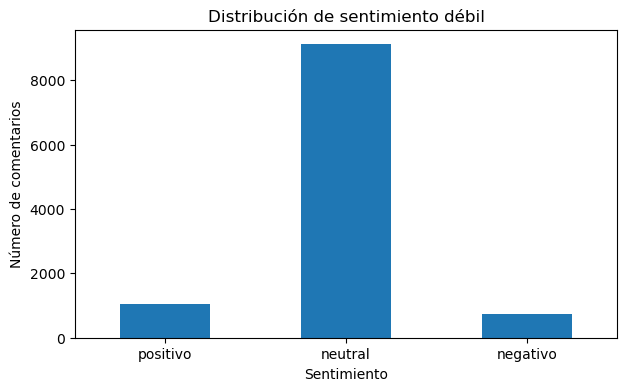

In [11]:
#solución
df["sentiment_score_weak"] = df['text_bow'].apply(weak_sentiment_score)
df["sentiment_weak"]       = df["sentiment_score_weak"].apply(label_from_score)

sentiment_dist = (
    df["sentiment_weak"]
    .value_counts()
    .reindex(["positivo", "neutral", "negativo"])
    .fillna(0)
    .astype(int)
)
print("Distribución absoluta:")
display(sentiment_dist)

print("\nDistribución porcentual:")
display((100 * sentiment_dist / sentiment_dist.sum()).round(2).to_frame("%"))

# Gráfico
plt.figure(figsize=(7, 4))
sentiment_dist.plot(kind="bar")
plt.title("Distribución de sentimiento débil")
plt.xlabel("Sentimiento")
plt.ylabel("Número de comentarios")
plt.xticks(rotation=0)
plt.show()

---
### Ejercicio 7: Casos ambiguos del modelo léxico (2 puntos)

El modelo basado en léxico falla en casos donde la señal textual es contradictoria. Construye un DataFrame `ambiguous` con los comentarios que cumplan **al menos una** de estas condiciones:

- Tienen risas o emojis **y** han sido etiquetados como `negativo`.
- Tienen muchos likes (≥ `like_threshold` calculado en 1.5) **y** han sido etiquetados como `negativo`.
- Tienen 3 palabras o menos **y** no son `neutral`.

Muestra los 15 casos con más likes, ordenados por `likes` descendente.

In [12]:
#solución
ambiguous = df[
    ((df['has_laugh'] == True) | (df['has_emoji'] == True)) & (df['sentiment_weak'] == "negativo") | #Comparacion 1
    (df['likes'] >= like_threshold) & (df['sentiment_weak'] == "negativo") | #Comparacion 2
    (df['num_words'] <= 3) & (df['sentiment_weak'] != "neutral")   #Comparacion 3
].copy()

print(f"Comentarios ambiguos detectados: {len(ambiguous)}")

display(
    ambiguous[["likes", "num_words", "has_laugh", "has_emoji",
               "sentiment_weak", "sentiment_score_weak", "text"]]
    .sort_values("likes", ascending=False) # completa aquí 
)

Comentarios ambiguos detectados: 722


,likes,num_words,has_laugh,has_emoji,sentiment_weak,sentiment_score_weak,text
7426,1582,10888,False,True,negativo,-1,4:52 JAJAJAJ nadie notó el troleo 🤣
2985,704,10888,False,True,negativo,-1,Pelea que nadie pidió y ya
1723,580,10888,False,True,negativo,-1,me toco viendo a thegrefg pero nadie va a leer...
3685,521,10888,False,True,negativo,-2,El combate que nadie pedía y nadie necesitaba
2913,415,10888,False,True,negativo,-1,le pagaron bastante a esa que grita en cada co...
...,...,...,...,...,...,...,...
4170,0,10888,False,True,negativo,-2,A los 27 años quien esta viejo? Y roro tiene c...
1272,0,10888,False,True,negativo,-3,Unas de las peores ediciones de la velada se v...
1281,0,10888,False,True,negativo,-1,que mala velada
4128,0,10888,False,True,negativo,-1,El peor combate


---
## Parte 3 — Descubrimiento automático de temas con TF-IDF + NMF

En el Ejercicio 4 hemos construido una matriz TF-IDF con unigramas y bigramas.  Ahora vamos a reutilizar esa representación para descubrir automáticamente temas latentes mediante NMF.

La idea es que NMF descompone la matriz documento-término en dos matrices:

- una matriz que relaciona comentarios con temas;
- una matriz que relaciona temas con términos.

A partir de estas matrices podremos:

1. identificar los términos principales de cada tema;
2. asignar a cada comentario su tema dominante;
3. leer ejemplos reales para interpretar manualmente los temas.

Antes de nada, ejecuta el siguiente código:

In [13]:
from sklearn.decomposition import NMF

required_objects = ["X_tfidf", "tfidf_vectorizer", "df"]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise ValueError(
        "Faltan objetos necesarios para este ejercicio: "
        + ", ".join(missing)
        + ". Ejecuta antes el Ejercicio 1.4."
    )

raw_text_col = "text"
text_col = "text_bow"

if raw_text_col not in df.columns:
    raw_text_col = text_col

feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print("-" * 70)
print("MATRIZ TF-IDF HEREDADA DEL EJERCICIO 4")
print(f"Nº comentarios: {X_tfidf.shape[0]}")
print(f"Nº términos:     {X_tfidf.shape[1]}")


# Entrenar NMF
n_topics = 12
top_n_terms = 12

nmf_model = NMF(
    n_components=n_topics,
    init="nndsvda",
    random_state=42,
    max_iter=600
)

W = nmf_model.fit_transform(X_tfidf)   # documento -> tema
H = nmf_model.components_              # tema -> término


# Asignar a cada comentario su tema dominante
df_topics = df.copy()
df_topics["topic"] = W.argmax(axis=1)
df_topics["topic_strength"] = W.max(axis=1)


# Funciones auxiliares para interpretar los temas
def get_topic_terms(topic_id, n=12):
    """
    Devuelve los términos más importantes de un tema NMF.
    """
    weights = H[topic_id]
    top_idx = np.argsort(weights)[::-1][:n]

    return pd.DataFrame({
        "term": feature_names[top_idx],
        "weight": weights[top_idx]
    })


def mostrar_ejemplos_tema(
    topic_id,
    n=5,
    min_words=8,
    sentiment=None,
    max_chars=600
):
    topic_terms = topic_summary.loc[
        topic_summary["topic"] == topic_id, "top_terms"
    ].iloc[0]

    examples = df_topics[df_topics["topic"] == topic_id].copy()

    # Evitamos ejemplos demasiado cortos tipo "Velada", "Grande", "No", etc.
    if "num_words" in examples.columns:
        examples = examples[examples["num_words"] >= min_words]

    # Opcional: filtrar por sentimiento si existe la columna
    if sentiment is not None and "sentiment_weak" in examples.columns:
        examples = examples[examples["sentiment_weak"].eq(sentiment)]

    # Si el filtro deja el tema vacío, relajamos la restricción de longitud
    if examples.empty:
        examples = df_topics[df_topics["topic"] == topic_id].copy()

        if sentiment is not None and "sentiment_weak" in examples.columns:
            examples = examples[examples["sentiment_weak"].eq(sentiment)]

    # Criterio de ordenación:
    # - Si hay score de sentimiento, priorizamos ejemplos más claros semánticamente.
    # - Después usamos la fuerza del tema.
    sort_cols = []
    ascending = []

    if sentiment is not None and "sentiment_score_weak" in examples.columns:
        sort_cols.append("sentiment_score_weak")
        ascending.append(False)

    sort_cols.append("topic_strength")
    ascending.append(False)

    if "likes" in examples.columns:
        sort_cols.append("likes")
        ascending.append(False)

    examples = (
        examples
        .sort_values(sort_cols, ascending=ascending)
        .head(n)
    )

    print("-" * 70)
    print(f"TEMA {topic_id}")
    print("-" * 70)

    print(f"Nº comentarios:    {(df_topics['topic'] == topic_id).sum()}")

    if "sentiment_weak" in df_topics.columns:
        topic_df = df_topics[df_topics["topic"] == topic_id]
        n_pos = topic_df["sentiment_weak"].eq("positivo").sum()
        pct_pos = 100 * n_pos / len(topic_df)

        print(f"Nº positivos:      {n_pos}")
        print(f"% positivos:       {pct_pos:.2f}%")

    if "sentiment_score_weak" in df_topics.columns:
        mean_score = df_topics.loc[
            df_topics["topic"] == topic_id,
            "sentiment_score_weak"
        ].mean()

        print(f"Score medio:       {mean_score:.2f}")

    print("\nTérminos principales:")
    print(topic_terms)

    if sentiment is None:
        print("\nComentarios representativos:")
    else:
        print(f"\nEjemplos {sentiment}s:")

    for i, row in enumerate(examples.itertuples(), start=1):
        text = getattr(row, raw_text_col)
        strength = getattr(row, "topic_strength")

        if hasattr(row, "sentiment_score_weak"):
            score = getattr(row, "sentiment_score_weak")
            print(f"\n{i}. [score={score} | fuerza tema={strength:.3f}]")
        else:
            print(f"\n{i}. [fuerza tema={strength:.3f}]")

        print(str(text)[:max_chars])

# Resumen global de temas
topic_rows = []

for topic_id in range(n_topics):
    topic_terms = get_topic_terms(topic_id, n=top_n_terms)

    n_comments = (df_topics["topic"] == topic_id).sum()
    pct_comments = 100 * n_comments / len(df_topics)

    avg_strength = df_topics.loc[
        df_topics["topic"] == topic_id,
        "topic_strength"
    ].mean()

    topic_rows.append({
        "topic": topic_id,
        "n_comments": n_comments,
        "pct_comments": round(pct_comments, 2),
        "avg_strength": round(avg_strength, 4),
        "top_terms": ", ".join(topic_terms["term"].tolist()),
        "nombre_interpretativo": ""
    })

topic_summary = (
    pd.DataFrame(topic_rows)
    .sort_values("n_comments", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "-" * 70)
print("TEMAS DESCUBIERTOS AUTOMÁTICAMENTE")
display(topic_summary)

----------------------------------------------------------------------
MATRIZ TF-IDF HEREDADA DEL EJERCICIO 4
Nº comentarios: 10888
Nº términos:     9280

----------------------------------------------------------------------
TEMAS DESCUBIERTOS AUTOMÁTICAMENTE


,topic,n_comments,pct_comments,avg_strength,top_terms,nombre_interpretativo
0,0,2207,20.27,0.0277,"no, conozco, no conozco, verdad, esperaba, nad...",
1,7,1322,12.14,0.0416,"gero, viruzz, va, viruz, arias, gero arias, ga...",
2,10,1219,11.20,0.0479,"gaston, edul, edu, dale, aguirre, vamos gaston...",
3,2,1212,11.13,0.0344,"velada, mejor, mejor velada, combate, velada a...",
4,11,945,8.68,0.0531,"ibai, viruzz, gracias, bien, combates, ibai no...",
5,5,896,8.23,0.0571,"lit, keo, killah, lit killah, kidd, kidd keo, ...",
6,4,743,6.82,0.0633,"vs, messi, who, cr7, illojuan, vs messi, grefg...",
7,9,688,6.32,0.0625,"roro, rivers, vamos roro, va, vamos rivers, te...",
8,3,605,5.56,0.0903,"pelea, buena, mejor pelea, unica, unica pelea,...",
9,1,458,4.21,0.0890,"vamos, vamos gaston, vamos rivers, vamos lit, ...",


### Ejercicio 8 (1,5 puntos)

Analiza el código anterior y responde a las siguientes preguntas:

1. ¿Qué temas generales aparecen en `topic_summary`?
2. Elige dos temas y usa `mostrar_ejemplos_tema(topic_id, n=5)`. ¿Los comentarios representativos confirman la interpretación sugerida por los términos?
3. ¿Qué pasaría si usáramos menos temas? ¿Y más temas?

### Reflexión Ejercicio 8
#solución

Podemos establecer 4 categorías principales:
 - Participantes específicos
 - Organización del evento
 - Reacciones del público
 - Comparativas


---

In [14]:
#End of party :)!
mostrar_ejemplos_tema(topic_id=3, n=5)
mostrar_ejemplos_tema(topic_id=10, n=5)

----------------------------------------------------------------------
TEMA 3
----------------------------------------------------------------------
Nº comentarios:    605
Nº positivos:      99
% positivos:       16.36%
Score medio:       0.15

Términos principales:
pelea, buena, mejor pelea, unica, unica pelea, ver, buena pelea, va, pelea va, ser, mejor, estelar

Comentarios representativos:

1. [score=0 | fuerza tema=0.409]
Pelea de autismo

2. [score=0 | fuerza tema=0.409]
LA PELEA DE......... quienes son ellas?

3. [score=0 | fuerza tema=0.409]
Wua que pelea

4. [score=0 | fuerza tema=0.409]
Que asquerosidad de pelea

5. [score=0 | fuerza tema=0.409]
esta pelea si safa
----------------------------------------------------------------------
TEMA 10
----------------------------------------------------------------------
Nº comentarios:    1219
Nº positivos:      95
% positivos:       7.79%
Score medio:       0.07

Términos principales:
gaston, edul, edu, dale, aguirre, vamos gaston, ed